Dans ce TP on va realiser l'implementation suivant XGBoost

XGBoost = Extreme Gradient Boosting.

C’est un algorithme supervisé basé sur plusieurs petits arbres de décision.

L’idée :

On commence par une prédiction simple, par exemple la moyenne des prix.
On calcule l’erreur :
- résidu = vraie valeur - prédiction
On entraîne un petit arbre pour prédire cette erreur.
On ajoute cette correction à la prédiction.
On répète plusieurs fois.

Donc chaque nouvel arbre essaie de corriger les erreurs des arbres précédents.

Exemple intuitif

Tu veux prédire le prix d’une maison.

Au début, le modèle dit :

prix moyen = 1200

Mais une maison vaut réellement :

1500

Erreur :

1500 - 1200 = 300

Le prochain arbre apprend à corriger ce +300.

Après plusieurs arbres, la prédiction devient meilleure.

Différence avec Random Forest

Random Forest :

plusieurs arbres indépendants
résultat moyen ou vote

XGBoost :

arbres construits séquentiellement
chaque arbre corrige le précédent
Paramètres importants
n_estimators : nombre d’arbres
learning_rate : importance de chaque arbre
max_depth : profondeur des arbres
régularisation : éviter l’overfitting

Dans notre TP, on va faire une version simplifiée avec des petits arbres de profondeur 1, appelés decision stumps.

In [1]:
# Importation de NumPy pour les calculs numériques
import numpy as np

# Importation de Pandas pour créer et manipuler le dataset
import pandas as pd

# Importation de Matplotlib pour les graphes
import matplotlib.pyplot as plt

In [2]:
# Fixer une graine aléatoire permet d'obtenir les mêmes résultats à chaque exécution
np.random.seed(10)

# Nombre d'observations
m = 120

# Variables explicatives
superficie = np.random.randint(50, 230, m)
chambres = np.random.randint(1, 7, m)
age_maison = np.random.randint(0, 45, m)
distance_centre = np.round(np.random.uniform(1, 22, m), 2)

# Bruit aléatoire pour rendre les données plus réalistes
bruit = np.random.normal(0, 55, m)

# Création du prix
prix = (
    200
    + 8.0 * superficie
    + 70 * chambres
    - 5.0 * age_maison
    - 22 * distance_centre
    + bruit
)

# Création du DataFrame
df = pd.DataFrame({
    "superficie": superficie,
    "chambres": chambres,
    "age_maison": age_maison,
    "distance_centre": distance_centre,
    "prix": np.round(prix, 2)
})

# Export du dataset
df.to_csv("dataset_xgboost_simplifie.csv", index=False)

# Affichage des premières lignes
df.head()

,superficie,chambres,age_maison,distance_centre,prix
0,59,2,11,9.63,504.72
1,175,2,39,12.35,1250.64
2,65,5,17,16.19,560.04
3,114,1,39,19.55,618.72
4,163,1,33,4.25,1264.11


In [3]:
def split_train_test(X, y, test_ratio=0.2, seed=42):
    """
    Sépare les données en train/test sans utiliser scikit-learn.
    """
    np.random.seed(seed)

    indices = np.random.permutation(len(X))
    taille_test = int(len(X) * test_ratio)

    indices_test = indices[:taille_test]
    indices_train = indices[taille_test:]

    return X[indices_train], X[indices_test], y[indices_train], y[indices_test]


def mse(y_true, y_pred):
    """
    Mean Squared Error.
    Utilisée pour mesurer l'erreur en régression.
    """
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    """
    Root Mean Squared Error.
    Racine carrée de la MSE.
    """
    return np.sqrt(mse(y_true, y_pred))

In [5]:
# Un decision stump est un petit arbre de profondeur 1

# Il pose une seule question :

# feature <= seuil ?  

class DecisionStumpRegressor:
    """
    Petit arbre de régression de profondeur 1.
    Il cherche le meilleur split pour minimiser la MSE.
    """

    def __init__(self):
        self.feature_index = None
        self.threshold = None
        self.left_value = None
        self.right_value = None

    def fit(self, X, y):
        """
        Entraîne le stump.
        """
        n_samples, n_features = X.shape
        meilleur_score = float("inf")

        # Tester chaque variable
        for feature_index in range(n_features):

            # Tester chaque valeur comme seuil possible
            thresholds = np.unique(X[:, feature_index])

            for threshold in thresholds:

                # Séparation gauche/droite
                left_mask = X[:, feature_index] <= threshold
                right_mask = X[:, feature_index] > threshold

                # Éviter les groupes vides
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                # Moyenne des valeurs à gauche et à droite
                left_value = np.mean(y[left_mask])
                right_value = np.mean(y[right_mask])

                # Prédiction du stump
                y_pred = np.zeros(n_samples)
                y_pred[left_mask] = left_value
                y_pred[right_mask] = right_value

                # Calcul de la MSE
                score = mse(y, y_pred)

                # Garder le meilleur split
                if score < meilleur_score:
                    meilleur_score = score
                    self.feature_index = feature_index
                    self.threshold = threshold
                    self.left_value = left_value
                    self.right_value = right_value

    def predict(self, X):
        """
        Prédit avec le stump entraîné.
        """
        predictions = np.zeros(X.shape[0])

        left_mask = X[:, self.feature_index] <= self.threshold
        right_mask = X[:, self.feature_index] > self.threshold

        predictions[left_mask] = self.left_value
        predictions[right_mask] = self.right_value

        return predictions

In [6]:
class XGBoostSimplifieFromScratch:
    """
    Version simplifiée de XGBoost pour la régression.

    Chaque arbre apprend les résidus du modèle précédent.
    """

    def __init__(self, n_estimators=30, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.models = []
        self.initial_prediction = None
        self.train_errors = []

    def fit(self, X, y):
        """
        Entraîne le modèle.
        """

        # Prédiction initiale : moyenne de y
        self.initial_prediction = np.mean(y)

        # Toutes les prédictions commencent par cette moyenne
        y_pred = np.full(len(y), self.initial_prediction)

        # Entraîner plusieurs arbres successivement
        for i in range(self.n_estimators):

            # Calcul des résidus
            residuals = y - y_pred

            # Créer un petit arbre
            stump = DecisionStumpRegressor()

            # Le stump apprend à prédire les résidus
            stump.fit(X, residuals)

            # Correction prédite par le stump
            correction = stump.predict(X)

            # Mise à jour de la prédiction globale
            y_pred = y_pred + self.learning_rate * correction

            # Sauvegarder le stump
            self.models.append(stump)

            # Sauvegarder l'erreur actuelle
            self.train_errors.append(mse(y, y_pred))

    def predict(self, X):
        """
        Prédit avec tous les arbres.
        """

        # Commencer par la prédiction initiale
        y_pred = np.full(X.shape[0], self.initial_prediction)

        # Ajouter les corrections de chaque arbre
        for stump in self.models:
            y_pred = y_pred + self.learning_rate * stump.predict(X)

        return y_pred
    

In [7]:
# Variables explicatives
X = df[["superficie", "chambres", "age_maison", "distance_centre"]].values.astype(float)

# Variable cible
y = df["prix"].values.astype(float)

# Séparation train/test
X_train, X_test, y_train, y_test = split_train_test(X, y)

print("Taille train :", X_train.shape)
print("Taille test :", X_test.shape)

Taille train : (96, 4)
Taille test : (24, 4)


In [8]:
# Création du modèle
xgb_model = XGBoostSimplifieFromScratch(
    n_estimators=40,
    learning_rate=0.1
)

# Entraînement du modèle
xgb_model.fit(X_train, y_train)

print("Modèle XGBoost simplifié entraîné avec succès.")

Modèle XGBoost simplifié entraîné avec succès.


In [9]:
# Prédiction sur les données de test
y_pred = xgb_model.predict(X_test)

# Calcul des métriques
mse_test = mse(y_test, y_pred)
rmse_test = rmse(y_test, y_pred)

print("MSE test :", mse_test)
print("RMSE test :", rmse_test)

MSE test : 19973.681353544565
RMSE test : 141.32827513822053


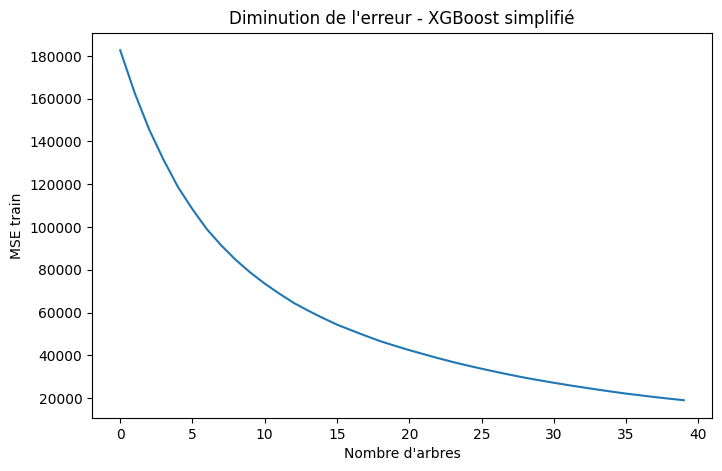

In [10]:
plt.figure(figsize=(8, 5))

# Si la courbe diminue, cela montre que chaque arbre corrige les erreurs précédentes
plt.plot(xgb_model.train_errors)

plt.xlabel("Nombre d'arbres")
plt.ylabel("MSE train")
plt.title("Diminution de l'erreur - XGBoost simplifié")

plt.savefig("erreur_xgboost_simplifie.png")

plt.show()

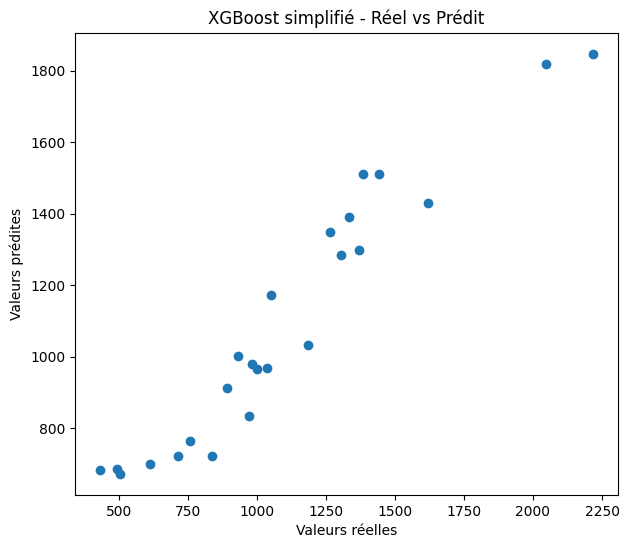

In [15]:
# Réel vs prédit
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("XGBoost simplifié - Réel vs Prédit")

plt.savefig("xgboost_reel_vs_predit.png")

plt.show()

In [14]:
# Tableau de resultats
resultats = pd.DataFrame({
    "prix_reel": y_test,
    "prix_predit": np.round(y_pred, 2),
    "erreur": np.round(y_test - y_pred, 2)
})

resultats.head(10)

,prix_reel,prix_predit,erreur
0,838.13,722.44,115.69
1,1443.13,1511.69,-68.56
2,1264.11,1348.05,-83.94
3,431.57,683.27,-251.70
4,2216.75,1847.08,369.67
5,972.97,834.03,138.94
6,1620.89,1430.44,190.45
7,1185.46,1031.55,153.91
8,758.69,764.98,-6.29
9,715.41,722.44,-7.03


In [13]:
print("Résumé XGBoost simplifié")
print("-------------------------")
print("Type :", "Apprentissage supervisé - Régression")
print("Principe :", "Boosting d'arbres")
print("Métriques :", "MSE et RMSE")
print("Dataset exporté :", "dataset_xgboost_simplifie.csv")
print("Graphes exportés :")
print("- erreur_xgboost_simplifie.png")
print("- xgboost_reel_vs_predit.png")

Résumé XGBoost simplifié
-------------------------
Type : Apprentissage supervisé - Régression
Principe : Boosting d'arbres
Métriques : MSE et RMSE
Dataset exporté : dataset_xgboost_simplifie.csv
Graphes exportés :
- erreur_xgboost_simplifie.png
- xgboost_reel_vs_predit.png
